# CSCI 3352 Biological Networks, Prof. Clauset
Submit here: https://canvas.colorado.edu/courses/101449

# Problem Set 1 : Fundamentals of Networks

***

**Name**: Dominic Galgano

***

This assignment is due on Canvas by **11:55pm on Friday, January 26**. Your solutions to non-programming questions should be done in Markdown directly below the associated question. Your solutions to computational questions should include any specified Python code and results as well as written commentary on your conclusions.  Remember that you are encouraged to discuss the problems with your classmates, but **you must write all code and solutions on your own** (see syllabus for detailed guidance). There are 88 points total, and 15 pts extra credit.

**NOTES**: 

- Unless a url is given for a data set, you will find the required data on the course Canvas.
- If you're not familiar with typesetting math directly in Markdown, you may do your work on paper first and then typeset it later. This [reference guide](https://math.meta.stackexchange.com/questions/5020/mathjax-basic-tutorial-and-quick-reference) provides helpful guidance for writing math in Markdown. 
- It is **unhelpful** to make your reader interpret numerical output from your code.  If a question asks you to compute some value from the data you should show your code output **AND** write a summary of the results in Markdown directly below your code.

***
* networkx [Documentation](https://networkx.github.io/documentation/stable/) and [Tutorial](https://networkx.github.io/documentation/stable/tutorial.html)
* igraph [Documentation](https://igraph.org/python/versions/latest/install.html) and [Tutorial](https://igraph.org/python/tutorial/0.9.8/tutorial.html)

In [1]:
import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pylab as plt
%matplotlib inline

***
## Problem 1 : Network warmup (33 pts total)

This problem gives you practice with performing basic operations on network data, using the `networkx` library. In order to answer these questions, you will need to search through the `networkx` online documentation to find appropriate functions. Some solutions will require you to write a little bit of your own code to process the input or output of those functions.

***
### Problem 1-A (5 pts)

Using `networkx`, load the assigned network data file as a simple graph, and then report the following:
* number of nodes $n$
* number of edges $m$
* mean degree $\langle k \rangle$

There are 3 network files provided. Enter your birthday in the format MMYY (drop a leading 0) as `seed` and then work with the file the code snippet below tells you is yours.

In [2]:
import random
seed = 626 # your MMYY birthday here

##### do not modify below here #####
random.seed(seed)
roll_the_dice = random.randint(1, 3)
if roll_the_dice == 1:
    print(f'Lucky you! Your file is karate.gml')
elif roll_the_dice == 2:
    print(f'Fantastic! Your file is grass_web.gml')
else:
    print(f'Exciting! Your file is yeast_spliceosome.gml')
##### do not modify above here #####

Fantastic! Your file is grass_web.gml


In [3]:
# Your code here
#Import the grass_web.gml into a networkx graph
grass_web = nx.read_gml("grass_web.gml", label='id')
#Gets the number of nodes and stores them in n
n = grass_web.number_of_nodes()
#Gets the number of edges and stores them in m
m = grass_web.number_of_edges()
#Calculates <k> using m and n from above
kmean = 2 * m / n

##### do not modify below here #####
print(f'number of nodes, n  = {n}')
print(f'number of edges, m  = {m}')
print(f'mean degree,    <k> = %5.2f' % kmean)

number of nodes, n  = 75
number of edges, m  = 113
mean degree,    <k> =  3.01


***
### Problem 1-B (6 pts)

Use the drawing functions in `networkx` to visualize your network in 3 ways:
* `spring` layout
* `circular` layout
* `random` layout

Use the function `plt.show()` to show the layout itself, once you've built it using `networkx`.

Then, write a few sentences comparing the layouts. Briefly explain what, if anything, does each show well or not well.

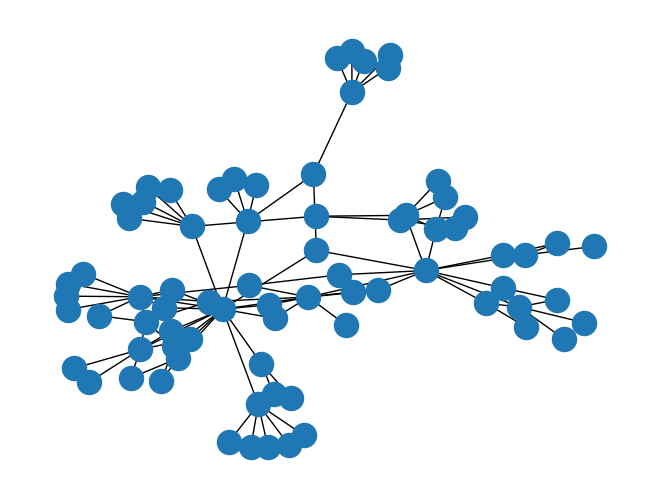

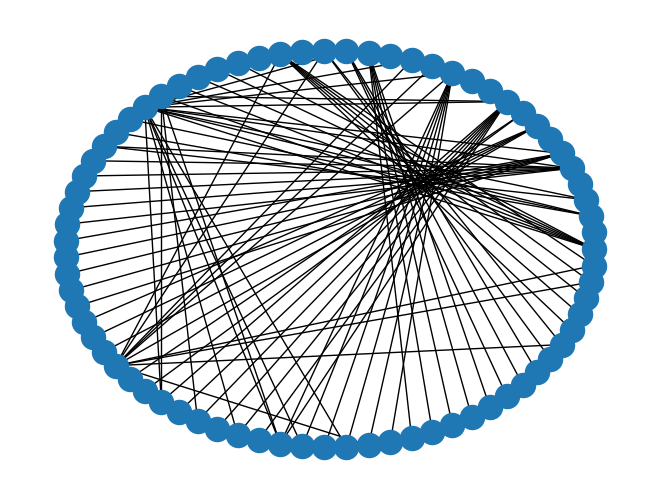

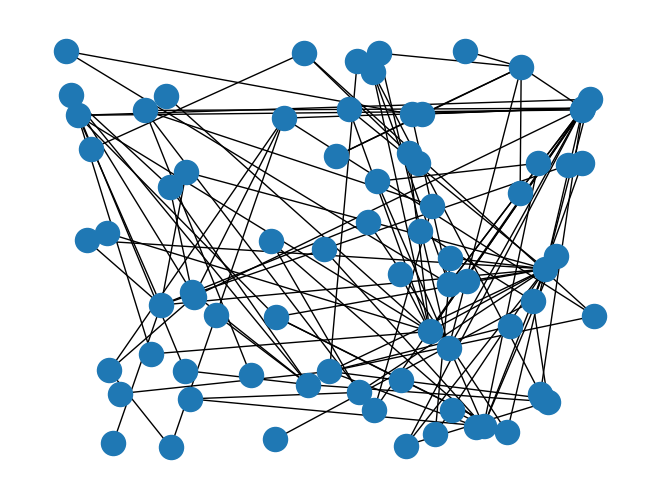

In [4]:
# Your code here
#Draws the spring layout of the grass_web graph
nx.draw(grass_web, pos=nx.spring_layout(grass_web))
plt.show()

#Draws the circular layout of the grass_web graph
nx.draw(grass_web, pos=nx.circular_layout(grass_web))
plt.show()

#Draws the random layout of the grass_web graph
nx.draw(grass_web, pos=nx.random_layout(grass_web))
plt.show()

* The **spring layout** 

Comparted to the circular and random layouts, the spring layout makes it easier to tell the relative distance between nodes as one can quickly see the a possible path between two nodes by glacing at the layout.
* The **circular layout**

Compared to the random layout, the circular layout makes it much more clear which nodes are hubs that connect many other nodes and which nodes are only connected to the rest of the graph by a signle edge. Compared to the spring layout, it makes it much easier to count all the edges a single node has, but more difficult to find paths in between nodes.
* The **random layout**

Compared to the circular and spring layouts, the random layout appears more spread out and visual confusing. Unlike the circular layout, it is difficult to count the number of edges connecting to a node, and unlike the spring layout it is very difficult to visually follow a path between two nodes in the graph.

***
### Problem 1-C (14 pts)

Using `networkx` functions, and any additional code you need to write, calculate and report the following network summary statistics:
* diameter $\ell_\max$
* mean geodesic path length $\langle \ell \rangle$
* clustering coefficient $C$ (aka, transitivity)
* number of connected components $h$
* maximum degree $k_{\rm max}$
* standard deviation of the degrees $\sigma_{k}$

Hint: the first four of these can be calculated using built-in functions from `networkx`; for the last two, you'll need to use the `.degrees(G)` function to obtain a dictionary of the degrees, and the process it yourself.

In [17]:
# Your code here
#Gets maximum diameter in graph
diameter = nx.diameter(grass_web, e=None)
#Gets average shorest path from graph
ellmean = nx.average_shortest_path_length(grass_web)
#Gets transitivity of graph
C = nx.transitivity(grass_web)


h = nx.number_connected_components(grass_web)

#Finds the node with the maximum degree
kmax = 0
for node in grass_web:
    nd = grass_web.degree(node)
    if nd > kmax:
        kmax = nd

#Finds the standard deviation of degrees between nodes  
kstd = np.std(grass_web)

##### do not modify below here #####
print(f'diameter = {diameter}')
print(f'mean geodesic distance, <ell> = %5.2f' % ellmean)
print(f'clustering coefficient, C     = %5.2f' % C)
print(f'number of components,   h     =  {h}')
print(f'max degree, k_max = {kmax}')
print(f'standard deviation of the degrees, k_std = %5.2f' % kstd)

diameter = 8
mean geodesic distance, <ell> =  3.87
clustering coefficient, C     =  0.17
number of components,   h     =  1
max degree, k_max = 17
standard deviation of the degrees, k_std = 24.19


***
### Problem 1-D (8 pts)

Using the provided functions, make **four** plots of the degree distribution:
* a `bar` plot of the probability density function (PDF; aka, a simple histogram), showing $\Pr(k)$ vs. $k$
* a `semilogx` plot of the PDF, showing $\Pr(k)$ vs. $\log_{10} k$
* a `loglog` plot of the PDF, showing $\log_{10} \Pr(k)$ vs. $\log_{10} k$
* a `loglog` plot of the complementary cumulative distribution function (CCDF), showing $\log_{10} \Pr(K\geq k)$ vs. $\log_{10} k$

Then comment briefly on the aspects of the degree distribution's shape that each plot over- or under-emphasizes, or shows clearly.

In [31]:
def plot_PDFhist(kis):
    # input : a list of degrees, e.g., from a networkx graph G
    # output: a plot of the PDF of the degree distribution Pr(k) as a simple histogram for k>=1
    
    kmax = max(kis)

    # histogram and plot
    counts, bins = np.histogram(kis, bins=[i for i in range(kmax+2)], density=True)
    plt.bar(bins[1:-1], counts[1:], facecolor='r', alpha=0.5)    
    plt.xlabel('Degree, k')
    plt.ylabel('Pr(k)')
    plt.title("PDF Hist")
    plt.show()
    return

def plot_PDFsemi(kis):
    # input : a list of degrees, e.g., from a networkx graph G
    # output: a plot of the PDF of the degree distribution Pr(k) on semi-log axes for k>=1
    
    kmax = max(kis)

    # histogram and plot
    counts, bins = np.histogram(kis, bins=[i for i in range(kmax+2)], density=True)
    plt.semilogx(bins[1:-1], counts[1:], 'rs-', alpha=0.5)
    plt.xlabel('Degree, k')
    plt.ylabel('Pr(k)')
    plt.title("PDF Semi")
    plt.show()
    return

def plot_PDFloglog(kis):
    # input : a list of degrees, e.g., from a networkx graph G
    # output: a plot of the PDF of the degree distribution Pr(k) on log-log axes for k>=1
    
    kmax = max(kis)

    # histogram and plot
    counts, bins = np.histogram(kis, bins=[i for i in range(kmax+2)], density=True)
    plt.loglog(bins[1:-1], counts[1:], 'rs', alpha=0.5)
    plt.xlabel('Degree, k')
    plt.ylabel('Pr(k)')
    plt.title("PDF Log-Log")
    plt.show()
    return

def plot_CCDF(kis):
    # input : a list of degrees, e.g., from a networkx graph G
    # output: a plot of the CCDF of the degree distribution Pr(K>=k) for k>=1
    
    kmax = max(kis)

    # histogram and plot
    counts, bins = np.histogram(kis, bins=[i for i in range(kmax+2)], density=True)
    cumcounts = np.cumsum(counts)
    cumcounts = np.insert(cumcounts,0,0)
    plt.loglog(bins[1:-1], 1-cumcounts[1:-1], 'rs', alpha=0.5)
    plt.xlabel('Degree, k')
    plt.ylabel('Pr(K>=k)')
    plt.title("CCDF")
    plt.show()
    return

[7, 2, 4, 3, 2, 8, 7, 3, 5, 3, 11, 1, 3, 9, 2, 3, 3, 6, 5, 4, 1, 7, 1, 1, 2, 2, 1, 6, 17, 4, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 3, 3, 11, 1, 1, 3, 1, 2, 1, 2, 1, 4, 2, 1, 2, 3, 2, 4, 1, 3, 2, 3, 1, 1, 1, 2, 3, 2, 2, 1, 3, 3]


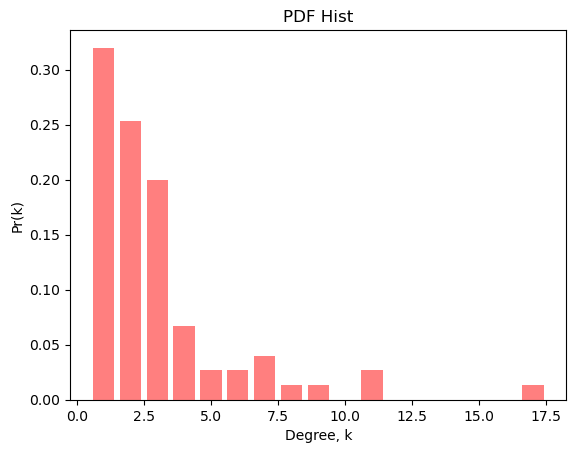

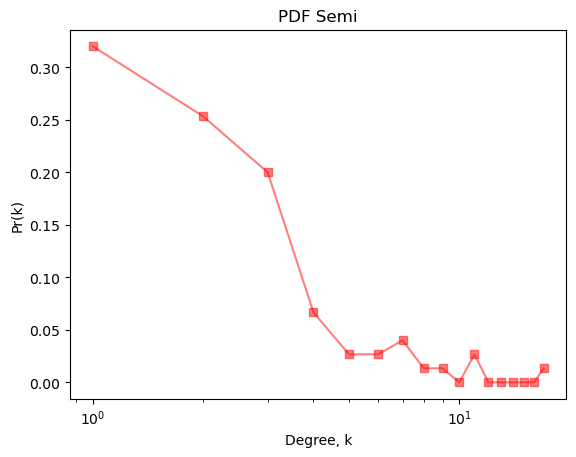

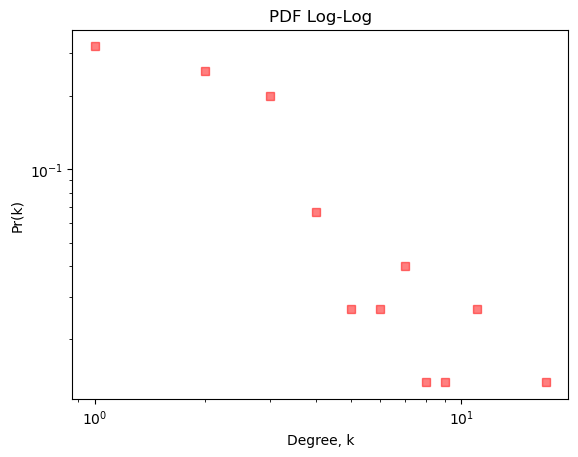

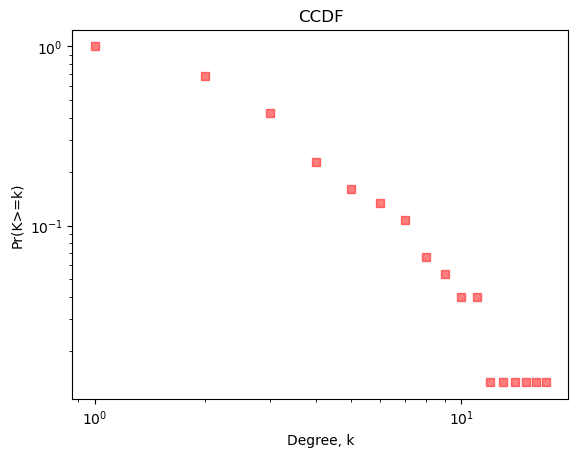

In [33]:
# Your code here

#Builds a list of degrees
degreeList = []

for node in grass_web:
    degree = grass_web.degree(node)
    degreeList.append(degree)
    
print(degreeList)

#Runs the given functions using the degree list
plot_PDFhist(degreeList)
plot_PDFsemi(degreeList)
plot_PDFloglog(degreeList)
plot_CCDF(degreeList)

The PDF histogram plot makes it very clear that most of the degree values are small, within the range of 1-5, but makes the heavy tail visually less clear given the large space in between the main concentration and the maximum degree

The PDF semi plot makes it clear the distribution does in fact have a heavy tail overall, but does not display the trend well with its down-up-down display

The PDF log-log plot makes it difficult to discern the heavy tail or the general trend given it looks more like a scatter plot than a probability density function

The CCDF makes it very clear how the data is distributed and also displays the heavy tail towards the right very well

***
***
## Problem 2 : Graph properties (30 pts total)

Read each of the following written descriptions of a network data set. Then list in Markdown all applicable _graph properties_ that network has, from the following list.
* directed or undirected
* weighted or unweighted or signed
* bipartite
* temporal
* multiplex
* multigraph
* metadata

***
### Problem 2-A (5 pts)
A network of genes and the $k$-mers they contain, for some fixed choice of $k$ (e.g., $k=3$). Nodes are either the DNA sequence of a full gene or the sequence of a particular $k$-mer, and each gene is connected to all the $k$-mers it contains.

**Answer**: 
    <br/>Directed because DNA and k-mers must be read in order
    <br/>Metadata because a full DNA sequence node is like a summarizing graph of a bunch of k-mer graphs

***
### Problem 2-B (5 pts)
A network of proteins and their pairwise interactions. Each node is a protein, and a pair of nodes $i,j$ are connected if protein $i$ binds to protein $j$ _in vivo_. Edges are annotated with the corresponding (real-valued) binding affinity, and nodes are annotated with their molecular weight.

**Answer**: 
    <br/>Undirected because of pairwise interactions
    <br/>Weighted because edges are annotated with corresponding binding affintiy value, nodes are annoted with molecular weight

***
### Problem 2-C (5 pts)
A sequence of network snapshots representing the spread over time of a communicable disease (e.g., influenza) through a human population. Every snapshot contains the same set of nodes, and the $t$-th snapshot contains all the edges that occurred in the real-time interval of $[t,t+1)$. Nodes are people, and two people $i,j$ are connected in the $t$-th snapshot if $j$ was infected by $i$ within the interval $[t,t+1)$. Nodes are annotated by the person's age and sex.

**Answer**: 
    <br/>Temporal because snapshots repesent the spread over time
    <br/>Directed because one person infects the other person
    <br/>Biparte because the infected group cannot infect fellow members of the infected group; healthy people cannot spread more health to other healthy people


***
### Problem 2-D (5 pts)
A gene regulatory network where nodes are genes, and an edge exists if gene $i$ regulates gene $j$, in two layers. Edges are annotated as being either an activation (layer 1) or an inhibition (layer 2) type of interaction. Genes are annotated by their [Gene Ontology](http://geneontology.org) (GO) functional class label.

**Answer**: 
    <br/>Directed because gene i regulates gene j
    <br/>Multiplex because edges indicate activation layer or inhibiton layer

***
### Problem 2-E (5 pts)
A network of proteins in a signaling pathway. Each node is a protein, and a pair of nodes $i,j$ are connected if $i$ binds to $j$. Edges are annotated with the effect of the binding, either activation or inhibition.

**Answer**: 
<br/>Undirected because i and j are only connected
<br/>Multiplex because edges indicate ativation or inhition

***
### Problem 2-F (5 pts)
A network of disease and gene associations, where nodes are either diseases or genes, and a disease $i$ and a gene $j$ are connected if $j$ is associated (in some way) with the incidence of $i$. Disease are annotated with various information about them, e.g., their name, treatment, symptoms list, etc., and genes are annotated with the DNA sequence.

**Answer**: 
<br/>Undirected because i and j have a shared edge if associated in some way
<br/>Metadata because diseases/genes are annotated with info about them

***
***

## Problem 3 : Calculations by hand (25 pts total)

For each of the following networks, calculate by hand:
* maximum degree $k_{\rm max}$
* minimum degree $k_{\rm min}$
* clustering coefficient $C$ (transitivity)
* diameter $\ell_\max$

Do not use software to do these calculations. Explain each calculation and show your work in Markdown in the corresponding box below.

Hint: If a specific network is given, you may give your answers as numbers. If a family of networks is given (e.g., one in which the number of nodes $n$ is not specified), your answers should be in terms of the variables that parameterize the network (e.g., $n$).

***
### Problem 3-A (5 pts)
Let $G$ be a fully connected simple network, aka, a complete graph, with $n$ nodes.

* maximum degree:
Given a fully connected simple network $k_{\rm max}$ = n - 1 becauase every node will have the same number of edges since they are connected to every other node

* minimum degree:
Given a fully connected simple network $k_{\rm min}$ = $k_{\rm max}$ = n - 1 becauase every node will have the same number of edges since they are connected to every other node

* clustering coefficient (transitivity):
Given a fully connected simple network $C$ = 1 because every potential triplet will be connected as a triangle since every node is connected to every other node

* diameter:
Given a fully connected simple network $\ell_\max$ = 1 because path length is equal to the number of edges between the intial node and the destiation node and every node is directly connected to every other node


***
### Problem 3-B (10 pts)

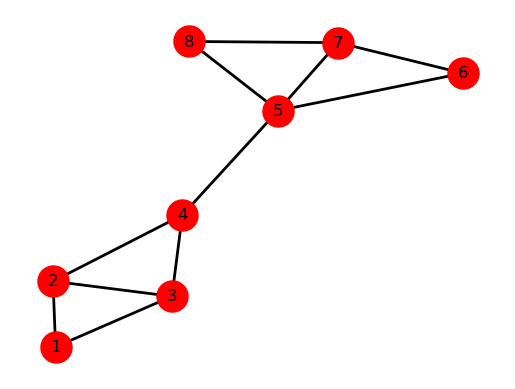

In [34]:
G = nx.Graph()          # empty graph data structure
# now, add a bunch of edges simultaneously
G.add_edges_from([(1,2), (1,3), (2,3), (2,4), (3,4), (4,5), (5,6), (5,7), (5,8), (6,7), (7,8)])
nx.draw_networkx(G,with_labels=True,node_size=500,node_color='r',width=2) # default: spring embed, with some options
limits=plt.axis('off')  # turn off the bounding box and axis labels
plt.show()              # show me the network!

* maximum degree:
$k_{\rm max}$ = 4 because by visual inspection it can be determined node 5 has the most edges and counting them all totals 4 edges for node 5.

* minimum degree:
$k_{\rm min}$ = 2 because by visual inspection it can be determined nodes 1, 6, and 8 all are tied for the least number of edges and counting the edges on each node totals to 2 edges.

* clustering coefficient (transitivity):
Given the bottom section(nodes 1,2,3,4) and top section(nodes 5,6,7,8) both form k<sub>4</sub> cliques therefore we can calculate the number of triangles as $2 * {4 \choose 2} = 12$. Next we can determine the total number of triplets as the $number-of-triangles + 4 $ given there are 4 remaining non-triangle triplets by visual inspection. Adding these we get $12 + 4 = 16$, therefore transitivity is $C = \frac{12}{16} = \frac{3}{4} $ or $0.75$

* diameter:
By visual inspection it can be determined the longest path is either between 1 and 6 or 1 and 8, therefore by counting the number of edges between the paths we find a diameter of $\ell_\max$ = 4

***
### Problem 3-C (5 pts)
Let $G$ be a _perfect_ binary tree containing $n$ nodes. Hint: how many nodes $n$ does a perfect binary tree contain, for depth $d=0,1,2,\dots$

(*extra credit*) Calculate the mean degree $\langle k \rangle$.

* maximum degree:
$k_{\rm max}$ = 3 because a node can only have 1 edge to its parent and 2 to its children

* minimum degree:
$k_{\rm min}$ = 1 if a node is a child node at the bottom of the tree only attached to its parent node

* clustering coefficient (transitivity):
$C = 0$ because even though the tree will likely have many triplets it won't have any connected triangles

* diameter: 
$\ell_\max = 2 * (log_2(n + 1) - 1)$ because given the graph is a perfect binary tree at any $n$ the longest path will be from the children lowest down on the left side of the tree to the children lowest down on the right side of the tree. To achieve this first we must traverse from the lowest left side children to the root node or the depth $d$ of the tree. Next we must traverse from the root to lowest right side child, again the depth $d$ of the tree. Therefore, with the knowledge that the depth is $log_2(n + 1) - 1$, the longest path can be found doubling this value.

***
### Problem 3-D (5 pts)
Let $G$ be a simple "ring" network with $n$ nodes, in which nodes are arranged in a line, each one connecting only to its immediate neighbors to the left and right, except for the nodes at the beginning and end of the line, which connect to each other. Below is an example for $n=6$, but state your answers for the general case of $n>0$.

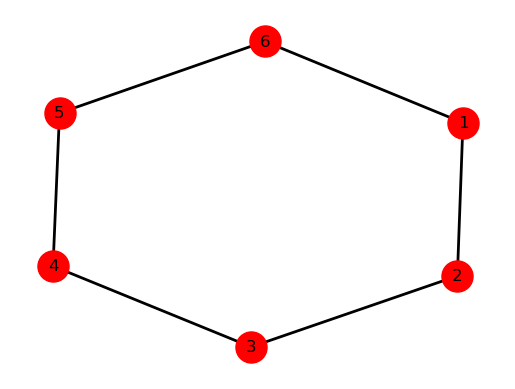

In [35]:
G = nx.Graph()          # empty graph data structur
G.add_edges_from([(1,2), (2,3), (3,4), (4,5), (5,6), (6,1)])
nx.draw_networkx(G,with_labels=True,node_size=500,node_color='r',width=2) # default: spring embed, with some options
limits=plt.axis('off')  # turn off the bounding box and axis labels
plt.show()              # show me the network!

* maximum degree:
<br/>$k_{\rm max} = n - 1$ when $2 >= n > 0$ because a simple graph cannot have more edges than nodes
<br/> $k_{\rm max} =2$ when $n > 2$ because a node can only have 2 edges if it is only connected to its neighbors in the cirlce of $n$ nodes

* minimum degree:
<br/>$k_{\rm min} = k_{\rm max}$ because the maximum number of edges must be equal to the minimum number of edges if every node has the same number of edges

* clustering coefficient (transitivity):
$C = 0$ because even though the circle will likely have many triplets it won't have any connected triangles

* diameter:
<br/>$\ell_\max = n / 2$ when $n > 1$ and $\ell_\max = 0$ otherwise because the furtherest path to traverse will be from one node to the node opposite of it on the circle                                           

***
***

## Problem 4 : Reading the literature (*10pts extra credit*)

*This extra credit problem is meant to help you look for a project topic*

Choose a paper from the [Supplemental Reading list on the external course webpage](https://aaronclauset.github.io/courses/3352/). Read the paper (the whole paper, not just the abstract). Think about what it says and what it finds. Read it again, if it's not clear. Then, write 1-3 sentences for each of the following questions in a way that clearly summarizes the work, and its context.
* What was the research question?
* What was the approach the authors took to answer that question?
* What did they do well?
* What could they have done better?
* What extensions can you envision?


Do not copy any text from the paper itself; write your own summary, in your own words in Markdown in the corresponding box below. Be sure to answer each of the five questions. The amount of extra credit will depend on the accuracy and thoughtfulness of your answers.

* *What paper did you choose?*<br/>
Give the Authors, Title, Publication Venue, Year
<br/>


* *What was the research question?*<br/>
Your answer here
<br/>

* *What was the approach the authors took to answer that question?*<br/>
Your answer here
<br/>

* *What did they do well?*<br/>
Your answer here
<br/>

* *What could they have done better?*<br/>
Your answer here
<br/>

* *What extensions can you envision?*<br/>
Your answer here